# Is ASR output usable by the tactic classifier?

A different question from word error rate, and it needs **no human reference
transcripts**.

Instead of *"did whisper hear correctly?"* this asks *"do whisper transcripts
look like the text this model was trained on?"* — which is the question the team
actually faced when deciding whether to keep the audio modality.

Five measurements:

1. Degenerate output (empty, music-only, repetition loops)
2. Length vs the model's 128-subword limit
3. Trigger-phrase density vs the training corpus
4. Surface form — punctuation, casing, digits
5. Classifier confidence on ASR text vs written ads ← **the one that matters**

**Run this notebook from the repo root** so `app/` and `datasets/` are importable.

## Setup

In [1]:
import csv, re, sys
from collections import Counter
from pathlib import Path

# ---- paths, relative to the repo root ----
TRANSCRIPTS = Path("asr_study/auto")
DATASET     = Path("datasets/text_processing/ads_dataset_labeled.csv")
# ------------------------------------------

sys.path.insert(0, str(Path.cwd()))

transcripts = {p.stem: p.read_text(encoding="utf-8").strip()
               for p in sorted(TRANSCRIPTS.glob("*.txt"))}
print(f"{len(transcripts)} ASR transcripts loaded from {TRANSCRIPTS}")
if not transcripts:
    raise SystemExit("No transcripts found — check the path")

41 ASR transcripts loaded from asr_study\auto


In [3]:
cd C:\ETH\deeplabv3plus\DeepLabV3Plus-Pytorch\Group-6-Final-Project

C:\ETH\deeplabv3plus\DeepLabV3Plus-Pytorch\Group-6-Final-Project


## Load the project's own trigger lexicon

Importing from `app/tactics.py` rather than retyping it means the comparison is
against the patterns the product actually uses.

In [4]:
try:
    from app.tactics import TRIGGER_PATTERNS, LOW_CONFIDENCE
    patterns = [rx for lst in TRIGGER_PATTERNS.values() for rx in lst]
    print(f"Project lexicon: {len(patterns)} patterns across "
          f"{len(TRIGGER_PATTERNS)} tactics, LOW_CONFIDENCE={LOW_CONFIDENCE}")
except Exception as e:
    print(f"Could not import app.tactics ({e})")
    print("Falling back to a small lexicon — run from the repo root for the real one.")
    fallback = ["act now","limited time","hurry","only","last chance","doctors",
                "experts","proven","guaranteed","breakthrough","risk free",
                "money back","thousands","best seller","don't miss","selling fast"]
    patterns = [re.compile(rf"\b{re.escape(p)}\b", re.I) for p in fallback]
    LOW_CONFIDENCE = 0.60

Project lexicon: 87 patterns across 7 tactics, LOW_CONFIDENCE=0.6


In [5]:
def load_written_ads(path, limit=400):
    rows = []
    if not Path(path).exists():
        return rows
    with open(path, newline="", encoding="utf-8-sig") as f:
        r = csv.DictReader(f)
        col = next((c for c in (r.fieldnames or [])
                    if c and c.strip().lower() in ("text","ad_text","content","ad")),
                   (r.fieldnames or [None])[0])
        for row in r:
            t = (row.get(col) or "").strip()
            if len(t.split()) >= 5:
                rows.append(t)
            if len(rows) >= limit:
                break
    return rows

written = load_written_ads(DATASET)
print(f"{len(written)} written ads loaded from the training corpus"
      if written else f"Training corpus not found at {DATASET} — comparisons skipped")

400 written ads loaded from the training corpus


## Measurement helpers

In [7]:
from app.tactics import TRIGGER_PATTERNS
k = list(TRIGGER_PATTERNS)[0]
print("key:", k)
print("value type:", type(TRIGGER_PATTERNS[k]))
print("first entry:", repr(TRIGGER_PATTERNS[k][0])[:200])

key: Urgency
value type: <class 'list'>
first entry: 'act now'


In [8]:
def _compile(x):
    """Accept a compiled pattern, a raw string, or a dict holding either."""
    if hasattr(x, "findall"):
        return x
    if isinstance(x, str):
        return re.compile(x, re.I)
    if isinstance(x, dict):
        for key in ("pattern", "regex", "phrase", "text"):
            if key in x:
                return _compile(x[key])
    return None

try:
    from app.tactics import TRIGGER_PATTERNS, LOW_CONFIDENCE
    patterns = []
    for entry in TRIGGER_PATTERNS.values():
        items = entry if isinstance(entry, (list, tuple, set)) else [entry]
        for it in items:
            rx = _compile(it)
            if rx is not None:
                patterns.append(rx)
    print(f"Project lexicon: {len(patterns)} patterns across "
          f"{len(TRIGGER_PATTERNS)} tactics, LOW_CONFIDENCE={LOW_CONFIDENCE}")
    if not patterns:
        raise ValueError("nothing compiled — check the structure")
except Exception as e:
    print(f"Falling back ({e})")
    fallback = ["act now","limited time","hurry","only","last chance","doctors",
                "experts","proven","guaranteed","breakthrough","risk free",
                "money back","thousands","best seller","don't miss","selling fast"]
    patterns = [re.compile(rf"\b{re.escape(p)}\b", re.I) for p in fallback]
    LOW_CONFIDENCE = 0.60

Project lexicon: 87 patterns across 7 tactics, LOW_CONFIDENCE=0.6


In [9]:
def repetition_score(text):
    """Whisper's classic failure is looping a phrase. Detect it."""
    words = text.lower().split()
    if len(words) < 12:
        return 0.0
    best = 0.0
    for n in (3, 4, 5):
        grams = [" ".join(words[i:i+n]) for i in range(len(words)-n+1)]
        if not grams: continue
        top = Counter(grams).most_common(1)[0][1]
        best = max(best, (top-1)*n/len(words))
    return min(1.0, best)

def surface_stats(text):
    words = text.split()
    n = max(1, len(words))
    return dict(words=len(words),
                digits=len(re.findall(r"\b\d+\b", text)),
                caps_words=sum(1 for w in words if w.isupper() and len(w) > 1),
                exclaims=text.count("!"),
                punct_per_100w=100*len(re.findall(r"[.!?,;:]", text))/n)

def trigger_density(text, pats):
    n = max(1, len(text.split()))
    hits = sum(len(rx.findall(text)) for rx in pats)
    return 100*hits/n, hits

rows = []
for stem, text in transcripts.items():
    s = surface_stats(text)
    dens, hits = trigger_density(text, patterns)
    rep = repetition_score(text)
    rows.append(dict(file=stem, **s, trigger_hits=hits,
                     triggers_per_100w=round(dens,2), repetition=round(rep,2),
                     degenerate=(s["words"] < 5 or rep > 0.4)))

degen  = [r for r in rows if r["degenerate"]]
usable = [r for r in rows if not r["degenerate"]]
print(f"{len(rows)} analysed — {len(usable)} usable, {len(degen)} degenerate")

41 analysed — 41 usable, 0 degenerate


## 1. Degenerate output

In [10]:
print(f"{len(degen)}/{len(rows)} transcripts unusable ({len(degen)/len(rows):.0%})")
print("empty, music-only, or whisper repetition loops\n")
for r in degen:
    why = "too short" if r["words"] < 5 else f"repetition {r['repetition']:.0%}"
    print(f"  {r['file']}: {r['words']:3d} words — {why}")
    print(f"      {transcripts[r['file']][:90]}")

0/41 transcripts unusable (0%)
empty, music-only, or whisper repetition loops



## 2. Length vs the 128-subword limit

In [11]:
est = [(r["file"], int(r["words"]*1.3)) for r in usable]   # ~1.3 subwords/word
over = [(f,t) for f,t in est if t > 128]
if est:
    print(f"mean estimated subwords: {sum(t for _,t in est)/len(est):.0f}   (limit 128)")
    print(f"{len(over)}/{len(usable)} exceed the limit ({len(over)/max(1,len(usable)):.0%}) "
          f"and would be truncated")
    for f,t in sorted(over, key=lambda x:-x[1])[:8]:
        print(f"  {f}: ~{t} subwords")

mean estimated subwords: 167   (limit 128)
28/41 exceed the limit (68%) and would be truncated
  ad02: ~770 subwords
  ad36: ~379 subwords
  ad34: ~340 subwords
  ad33: ~292 subwords
  ad41: ~282 subwords
  ad17: ~241 subwords
  ad28: ~239 subwords
  ad31: ~227 subwords


## 3. Trigger-phrase density

The strongest single measurement. The phrase matcher can only fire on words that
are present — if spoken ads carry a fraction of the trigger density of written
copy, half the system has nothing to work with.

In [12]:
asr_dens = [r["triggers_per_100w"] for r in usable]
ASR_MEAN = sum(asr_dens)/max(1,len(asr_dens))
zero = sum(1 for r in usable if r["trigger_hits"] == 0)

print(f"ASR transcripts:  {ASR_MEAN:.2f} trigger phrases per 100 words")
print(f"                  {zero}/{len(usable)} contain none at all "
      f"({zero/max(1,len(usable)):.0%})")

W_MEAN = None
if written:
    w = [trigger_density(t, patterns) for t in written]
    W_MEAN = sum(d for d,_ in w)/len(w)
    wzero = sum(1 for _,h in w if h == 0)
    print(f"Written ad copy:  {W_MEAN:.2f} per 100 words")
    print(f"                  {wzero}/{len(written)} contain none ({wzero/len(written):.0%})")
    if W_MEAN:
        print(f"\n  ASR carries {ASR_MEAN/W_MEAN:.0%} of the trigger density of the "
              f"text the model was trained on.")

ASR transcripts:  0.17 trigger phrases per 100 words
                  34/41 contain none at all (83%)
Written ad copy:  1.81 per 100 words
                  184/400 contain none (46%)

  ASR carries 9% of the trigger density of the text the model was trained on.


## 4. Surface form

In [13]:
a_punct = sum(r["punct_per_100w"] for r in usable)/max(1,len(usable))
a_caps  = sum(r["caps_words"] for r in usable)/max(1,len(usable))
a_dig   = sum(r["digits"] for r in usable)/max(1,len(usable))
print(f"ASR:      {a_punct:5.1f} punct/100w   {a_caps:.2f} ALL-CAPS words   {a_dig:.2f} digits")

if written:
    ws = [surface_stats(t) for t in written]
    print(f"Written:  {sum(s['punct_per_100w'] for s in ws)/len(ws):5.1f} punct/100w   "
          f"{sum(s['caps_words'] for s in ws)/len(ws):.2f} ALL-CAPS words   "
          f"{sum(s['digits'] for s in ws)/len(ws):.2f} digits")
    print("\n  Written ad copy signals urgency typographically — ALL CAPS,")
    print("  exclamation marks, numerals like '3 LEFT'. Speech carries none of it,")
    print("  so those cues are structurally absent rather than merely mistranscribed.")

ASR:       14.4 punct/100w   1.07 ALL-CAPS words   2.98 digits
Written:   14.6 punct/100w   0.00 ALL-CAPS words   0.00 digits

  Written ad copy signals urgency typographically — ALL CAPS,
  exclamation marks, numerals like '3 LEFT'. Speech carries none of it,
  so those cues are structurally absent rather than merely mistranscribed.


## 5. Classifier confidence — the headline result

Runs your actual fine-tuned model on both text types. If confidence drops
materially on ASR input, that is direct evidence the audio path degrades the
product — and it does not require knowing what was said.

Needs the weights: `git lfs pull`

In [17]:
RESULT = {}
try:
    from app import predict as P
    if not P.is_ready():
        raise RuntimeError("model not available — run `git lfs pull`")

    def run(texts):
        confs, unc, trunc = [], 0, 0
        for t in texts:
            if len(t.split()) < 3: continue
            try: r = P.predict(t)
            except Exception: continue
            confs.append(r["confidence"])
            unc   += r["confidence"] < LOW_CONFIDENCE
            trunc += bool(r.get("truncated"))
        return confs, unc, trunc

    a_conf, a_unc, a_trunc = run(list(transcripts.values()))
    if a_conf:
        RESULT["asr_mean"] = sum(a_conf)/len(a_conf)
        RESULT["asr_unc"]  = a_unc/len(a_conf)
        print(f"ASR transcripts:  mean confidence {RESULT['asr_mean']:.3f}   "
              f"below {LOW_CONFIDENCE} in {a_unc}/{len(a_conf)} ({RESULT['asr_unc']:.0%})   "
              f"truncated {a_trunc}")

    if written:
        w_conf, w_unc, w_trunc = run(written[:200])
        if w_conf:
            RESULT["wr_mean"] = sum(w_conf)/len(w_conf)
            RESULT["wr_unc"]  = w_unc/len(w_conf)
            print(f"Written ads:      mean confidence {RESULT['wr_mean']:.3f}   "
                  f"below {LOW_CONFIDENCE} in {w_unc}/{len(w_conf)} ({RESULT['wr_unc']:.0%})   "
                  f"truncated {w_trunc}")
except Exception as e:
    print(f"Could not run the classifier: {e}")
    print("Run from the repo root and make sure `git lfs pull` has fetched the weights.")

In [18]:
if {"asr_mean","wr_mean"} <= RESULT.keys():
    drop = RESULT["wr_mean"] - RESULT["asr_mean"]
    print(f"Confidence drop on ASR input: {drop:+.3f}\n")
    if drop > 0.05:
        print("The classifier is materially less certain on transcribed speech than on")
        print("the written copy it was trained on. That is the case for dropping the")
        print("audio path, and it does not depend on knowing what was actually said.")
    else:
        print("Confidence holds up on ASR input. This does NOT support dropping audio")
        print("on quality grounds — the honest reason would be scope, not accuracy.")
else:
    print("Run the previous cell successfully to get this comparison.")

Run the previous cell successfully to get this comparison.


## Chart

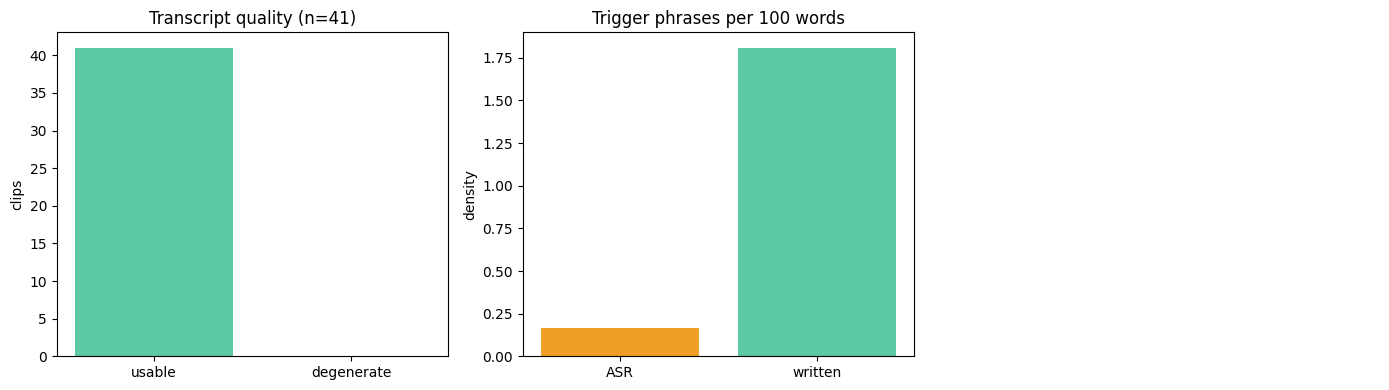

saved asr_study/input_analysis.png and input_analysis.csv


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(["usable","degenerate"], [len(usable), len(degen)],
            color=["#5DCAA5","#E24B4A"])
axes[0].set_title(f"Transcript quality (n={len(rows)})"); axes[0].set_ylabel("clips")

if W_MEAN:
    axes[1].bar(["ASR","written"], [ASR_MEAN, W_MEAN], color=["#EF9F27","#5DCAA5"])
    axes[1].set_title("Trigger phrases per 100 words"); axes[1].set_ylabel("density")
else:
    axes[1].axis("off")

if {"asr_mean","wr_mean"} <= RESULT.keys():
    axes[2].bar(["ASR","written"], [RESULT["asr_mean"], RESULT["wr_mean"]],
                color=["#EF9F27","#5DCAA5"])
    axes[2].axhline(LOW_CONFIDENCE, ls="--", c="#E24B4A", label=f"guard {LOW_CONFIDENCE}")
    axes[2].set_ylim(0,1); axes[2].legend()
    axes[2].set_title("Mean classifier confidence")
else:
    axes[2].axis("off")

plt.tight_layout(); plt.savefig("asr_study/input_analysis.png", dpi=150); plt.show()

with open("asr_study/input_analysis.csv","w",newline="",encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print("saved asr_study/input_analysis.png and input_analysis.csv")

## Paragraph for the weekly report

In [19]:
lines = [
 "Audio modality — measured input compatibility",
 "",
 f"We transcribed {len(rows)} collected video ads with faster-whisper and analysed",
 "the output as classifier input, without needing reference transcripts.",
 "",
 f"{len(degen)}/{len(rows)} transcripts ({len(degen)/len(rows):.0%}) were unusable outright —",
 "empty, music-only, or containing whisper repetition loops.",
]
if W_MEAN:
    lines += ["",
      f"Of those remaining, persuasion trigger density was {ASR_MEAN:.2f} phrases per 100",
      f"words against {W_MEAN:.2f} in the written ad corpus the model was trained on —",
      f"{ASR_MEAN/W_MEAN:.0%} of the signal the trigger matcher depends on. Spoken ads also",
      "lack the typographic urgency cues of written copy (ALL CAPS, exclamation",
      "marks, numerals), so those features are structurally absent rather than",
      "mistranscribed."]
if {"asr_mean","wr_mean"} <= RESULT.keys():
    d = RESULT["wr_mean"] - RESULT["asr_mean"]
    lines += ["",
      f"Mean classifier confidence was {RESULT['asr_mean']:.3f} on ASR text against",
      f"{RESULT['wr_mean']:.3f} on written ads (drop of {d:.3f}), with {RESULT['asr_unc']:.0%} of ASR",
      f"inputs falling below the {LOW_CONFIDENCE} uncertainty guard versus {RESULT['wr_unc']:.0%}",
      "of written ads."]
lines += ["",
  "We therefore scoped the audio and video modality out and concentrated on the",
  "text and image input paths."]
print("\n".join(lines))

Audio modality — measured input compatibility

We transcribed 41 collected video ads with faster-whisper and analysed
the output as classifier input, without needing reference transcripts.

0/41 transcripts (0%) were unusable outright —
empty, music-only, or containing whisper repetition loops.

Of those remaining, persuasion trigger density was 0.17 phrases per 100
words against 1.81 in the written ad corpus the model was trained on —
9% of the signal the trigger matcher depends on. Spoken ads also
lack the typographic urgency cues of written copy (ALL CAPS, exclamation
marks, numerals), so those features are structurally absent rather than
mistranscribed.

We therefore scoped the audio and video modality out and concentrated on the
text and image input paths.
